# Entrenamiento y Evaluación de Modelos
## Clasificador de Noticias: Actualidad vs Interés General

Este notebook entrena múltiples modelos de clasificación de texto y evalúa su rendimiento.

**Objetivos:**
1. Cargar los conjuntos de datos (train, val, test)
2. Vectorización de texto (TF-IDF)
3. Entrenar múltiples modelos de clasificación
4. Evaluar modelos con métricas completas
5. Seleccionar mejor modelo
6. Evaluación final en conjunto de test
7. Guardar modelo entrenado

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from datetime import datetime
import warnings

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas exitosamente")

Librerías importadas exitosamente


## 1. Cargar Conjuntos de Datos

In [2]:
# Cargar splits
train_df = pd.read_csv('../data/splits/train.csv')
val_df = pd.read_csv('../data/splits/val.csv')
test_df = pd.read_csv('../data/splits/test.csv')

print("Conjuntos de datos cargados:")
print(f"  - Training: {len(train_df):,} registros")
print(f"  - Validation: {len(val_df):,} registros")
print(f"  - Test: {len(test_df):,} registros")

# Separar texto y etiquetas
X_train_text = train_df['text']
y_train = train_df['label']

X_val_text = val_df['text']
y_val = val_df['label']

X_test_text = test_df['text']
y_test = test_df['label']

print("\nDistribución de clases:")
print(f"  Training: {y_train.value_counts().to_dict()}")
print(f"  Validation: {y_val.value_counts().to_dict()}")
print(f"  Test: {y_test.value_counts().to_dict()}")

Conjuntos de datos cargados:
  - Training: 145,178 registros
  - Validation: 41,427 registros
  - Test: 20,734 registros

Distribución de clases:
  Training: {1: 88084, 0: 57094}
  Validation: {1: 25135, 0: 16292}
  Test: {1: 12580, 0: 8154}


## 2. Vectorización de Texto con TF-IDF

In [3]:
# Crear vectorizador TF-IDF
print("Creando vectorizador TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=10000,        # Top 10,000 palabras más frecuentes
    ngram_range=(1, 2),        # Unigramas y bigramas
    min_df=2,                   # Ignorar términos que aparecen en menos de 2 documentos
    max_df=0.95,                # Ignorar términos que aparecen en más del 95% de documentos
    strip_accents='unicode',    # Eliminar acentos
    lowercase=True,             # Convertir a minúsculas
    stop_words='english'        # Eliminar stop words en inglés
)

# Fit en training y transform en todos los sets
print("\nVectorizando texto...")
X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)

print(f"\nForma de matrices:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"\nVocabulario: {len(vectorizer.vocabulary_):,} términos")

Creando vectorizador TF-IDF...

Vectorizando texto...



Forma de matrices:
  X_train: (145178, 10000)
  X_val: (41427, 10000)
  X_test: (20734, 10000)

Vocabulario: 10,000 términos


In [4]:
# Mostrar top términos por TF-IDF
feature_names = vectorizer.get_feature_names_out()
print("\nTop 30 términos del vocabulario:")
print(feature_names[:30])


Top 30 términos del vocabulario:
['000' '06' '10' '10 000' '10 best' '10 billion' '10 million' '10 months'
 '10 players' '10 things' '10 year' '10 years' '100' '100 000'
 '100 million' '100 years' '1000' '100k' '100m' '101' '102' '103' '105'
 '106' '108' '109' '10k' '10m' '10th' '11']


## 3. Entrenamiento de Modelos Baseline

In [5]:
# Diccionario para almacenar resultados
results = {}

def evaluate_model(model, X_val, y_val, model_name):
    """
    Evalúa un modelo y retorna métricas.
    """
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='binary'),
        'recall': recall_score(y_val, y_pred, average='binary'),
        'f1': f1_score(y_val, y_pred, average='binary'),
    }
    
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_val, y_proba)
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    if 'roc_auc' in metrics:
        print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    return metrics, y_pred, y_proba

### 3.1 Naive Bayes

In [6]:
print("="*60)
print("ENTRENANDO MODELO: Naive Bayes")
print("="*60)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(nb_model, X_val, y_val, "Naive Bayes")
results['Naive Bayes'] = {
    'model': nb_model,
    'metrics': metrics,
    'y_pred': y_pred,
    'y_proba': y_proba
}

ENTRENANDO MODELO: Naive Bayes

Naive Bayes:
  Accuracy:  0.8578
  Precision: 0.9024
  Recall:    0.8584
  F1-Score:  0.8799
  ROC-AUC:   0.9329


### 3.2 Logistic Regression

In [7]:
print("="*60)
print("ENTRENANDO MODELO: Logistic Regression")
print("="*60)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(lr_model, X_val, y_val, "Logistic Regression")
results['Logistic Regression'] = {
    'model': lr_model,
    'metrics': metrics,
    'y_pred': y_pred,
    'y_proba': y_proba
}

ENTRENANDO MODELO: Logistic Regression



Logistic Regression:
  Accuracy:  0.8659
  Precision: 0.9191
  Recall:    0.8541
  F1-Score:  0.8854
  ROC-AUC:   0.9382


### 3.3 Linear SVM

In [8]:
print("="*60)
print("ENTRENANDO MODELO: Linear SVM")
print("="*60)

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=2000
)
svm_model.fit(X_train, y_train)

# Note: LinearSVC no tiene predict_proba, solo decision_function
y_pred = svm_model.predict(X_val)
y_scores = svm_model.decision_function(X_val)

metrics = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='binary'),
    'recall': recall_score(y_val, y_pred, average='binary'),
    'f1': f1_score(y_val, y_pred, average='binary'),
    'roc_auc': roc_auc_score(y_val, y_scores)
}

print(f"\nLinear SVM:")
print(f"  Accuracy:  {metrics['accuracy']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1-Score:  {metrics['f1']:.4f}")
print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")

results['Linear SVM'] = {
    'model': svm_model,
    'metrics': metrics,
    'y_pred': y_pred,
    'y_proba': y_scores
}

ENTRENANDO MODELO: Linear SVM



Linear SVM:
  Accuracy:  0.8647
  Precision: 0.9191
  Recall:    0.8520
  F1-Score:  0.8843
  ROC-AUC:   0.9386


### 3.4 Random Forest

In [9]:
print("="*60)
print("ENTRENANDO MODELO: Random Forest")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=50
)
rf_model.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(rf_model, X_val, y_val, "Random Forest")
results['Random Forest'] = {
    'model': rf_model,
    'metrics': metrics,
    'y_pred': y_pred,
    'y_proba': y_proba
}

ENTRENANDO MODELO: Random Forest



Random Forest:
  Accuracy:  0.7307
  Precision: 0.9291
  Recall:    0.6021
  F1-Score:  0.7307
  ROC-AUC:   0.8736


## 4. Comparación de Modelos

In [10]:
# Crear tabla comparativa
comparison_data = []
for model_name, result in results.items():
    metrics = result['metrics']
    row = {
        'Model': model_name,
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'ROC-AUC': f"{metrics.get('roc_auc', 0):.4f}"
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("COMPARACIÓN DE MODELOS EN CONJUNTO DE VALIDACIÓN")
print("="*70)
display(comparison_df)

# Guardar tabla comparativa
comparison_df.to_csv('../results/model_comparison.csv', index=False)
print("\nTabla guardada en: ../results/model_comparison.csv")


COMPARACIÓN DE MODELOS EN CONJUNTO DE VALIDACIÓN


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Naive Bayes,0.8578,0.9024,0.8584,0.8799,0.9329
1,Logistic Regression,0.8659,0.9191,0.8541,0.8854,0.9382
2,Linear SVM,0.8647,0.9191,0.8520,0.8843,0.9386
3,Random Forest,0.7307,0.9291,0.6021,0.7307,0.8736



Tabla guardada en: ../results/model_comparison.csv


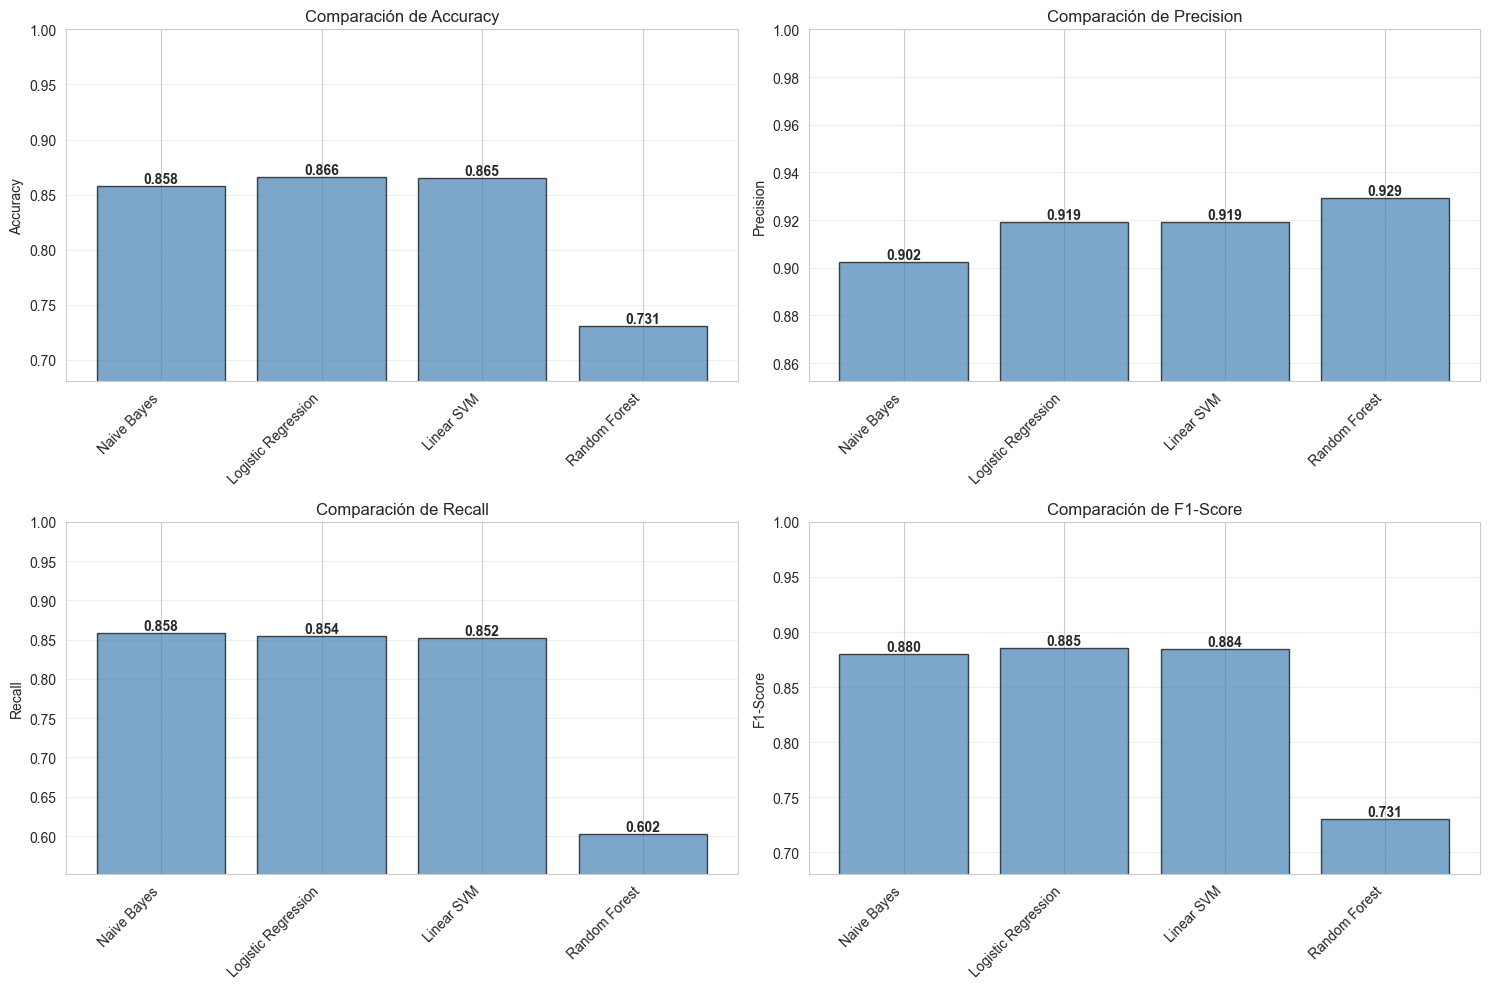

Gráfico guardado en: ../results/model_comparison_chart.png


In [11]:
# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, metric_name) in enumerate(zip(metrics_to_plot, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    model_names = list(results.keys())
    values = [results[name]['metrics'][metric] for name in model_names]
    
    bars = ax.bar(model_names, values, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_ylabel(metric_name)
    ax.set_title(f'Comparación de {metric_name}')
    ax.set_ylim([min(values) - 0.05, 1.0])
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Añadir valores en las barras
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: ../results/model_comparison_chart.png")

## 5. Selección del Mejor Modelo

In [12]:
# Seleccionar mejor modelo basado en F1-Score
best_model_name = max(results.keys(), key=lambda x: results[x]['metrics']['f1'])
best_model_data = results[best_model_name]
best_model = best_model_data['model']

print("="*60)
print("MEJOR MODELO SELECCIONADO")
print("="*60)
print(f"\nModelo: {best_model_name}")
print(f"\nMétricas en conjunto de validación:")
for metric, value in best_model_data['metrics'].items():
    print(f"  {metric.upper()}: {value:.4f}")
print("="*60)

MEJOR MODELO SELECCIONADO

Modelo: Logistic Regression

Métricas en conjunto de validación:
  ACCURACY: 0.8659
  PRECISION: 0.9191
  RECALL: 0.8541
  F1: 0.8854
  ROC_AUC: 0.9382


## 6. Matrices de Confusión

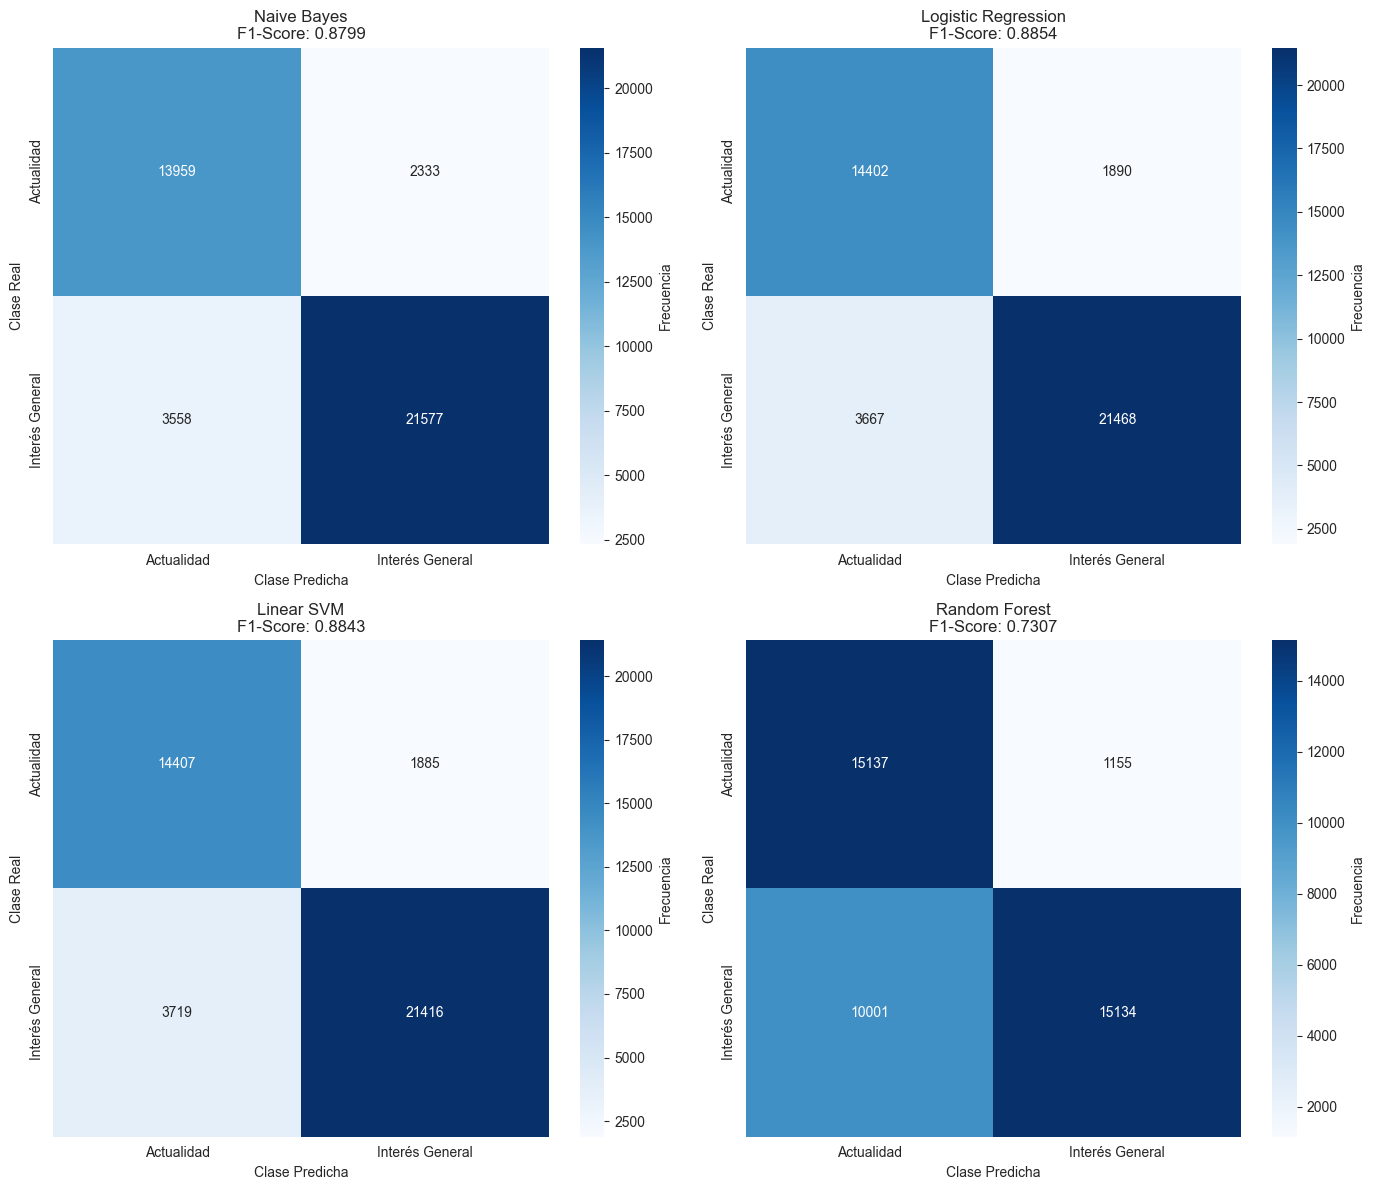

Matrices de confusión guardadas en: ../results/confusion_matrices.png


In [13]:
# Crear matrices de confusión para todos los modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

class_names = ['Actualidad', 'Interés General']

for idx, (model_name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_val, result['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Frecuencia'})
    axes[idx].set_ylabel('Clase Real')
    axes[idx].set_xlabel('Clase Predicha')
    axes[idx].set_title(f'{model_name}\nF1-Score: {result["metrics"]["f1"]:.4f}')

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Matrices de confusión guardadas en: ../results/confusion_matrices.png")

## 7. Curvas ROC

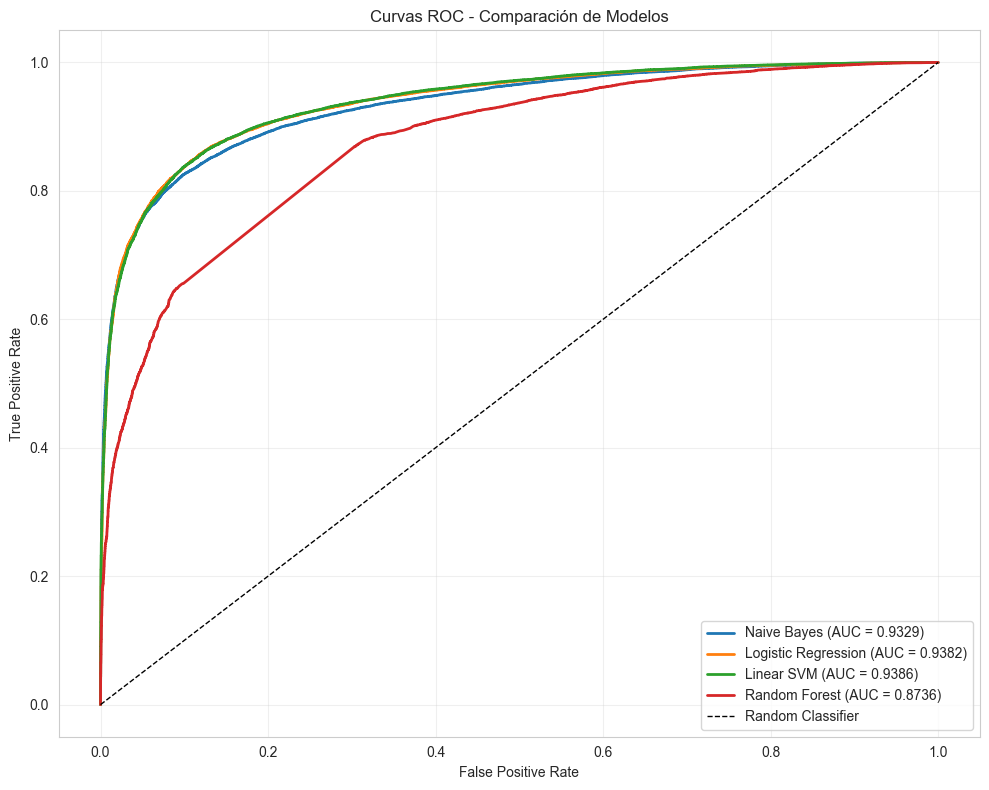

Curvas ROC guardadas en: ../results/roc_curves.png


In [14]:
# Crear curvas ROC
plt.figure(figsize=(10, 8))

for model_name, result in results.items():
    if result['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_val, result['y_proba'])
        auc = result['metrics'].get('roc_auc', 0)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Curvas ROC guardadas en: ../results/roc_curves.png")

## 8. Reporte de Clasificación del Mejor Modelo

In [15]:
# Reporte de clasificación detallado
print("="*60)
print(f"REPORTE DE CLASIFICACIÓN - {best_model_name}")
print("="*60)
print(classification_report(y_val, best_model_data['y_pred'], 
                          target_names=class_names, 
                          digits=4))
print("="*60)

REPORTE DE CLASIFICACIÓN - Logistic Regression
                 precision    recall  f1-score   support

     Actualidad     0.7971    0.8840    0.8383     16292
Interés General     0.9191    0.8541    0.8854     25135

       accuracy                         0.8659     41427
      macro avg     0.8581    0.8690    0.8618     41427
   weighted avg     0.8711    0.8659    0.8669     41427



## 9. Evaluación Final en Conjunto de Test

EVALUACIÓN FINAL EN CONJUNTO DE TEST

Modelo: Logistic Regression

Métricas finales en conjunto de test:
  ACCURACY: 0.8668
  PRECISION: 0.9202
  RECALL: 0.8545
  F1: 0.8862
  ROC_AUC: 0.9379

Reporte de clasificación detallado:
                 precision    recall  f1-score   support

     Actualidad     0.7978    0.8857    0.8395      8154
Interés General     0.9202    0.8545    0.8862     12580

       accuracy                         0.8668     20734
      macro avg     0.8590    0.8701    0.8628     20734
   weighted avg     0.8721    0.8668    0.8678     20734



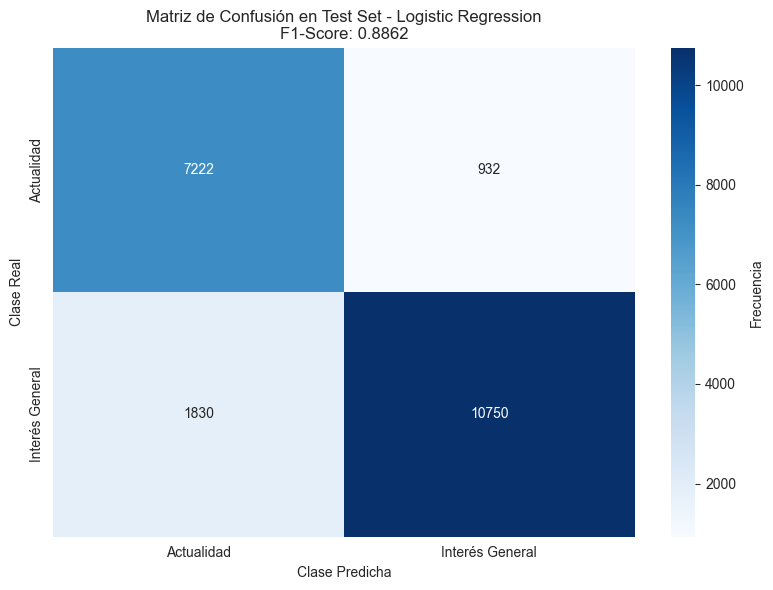


Matriz de confusión guardada en: ../results/confusion_matrix_test.png


In [16]:
# Evaluar mejor modelo en conjunto de test
print("="*60)
print("EVALUACIÓN FINAL EN CONJUNTO DE TEST")
print("="*60)

y_test_pred = best_model.predict(X_test)

# Obtener probabilidades o scores
if hasattr(best_model, 'predict_proba'):
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, 'decision_function'):
    y_test_proba = best_model.decision_function(X_test)
else:
    y_test_proba = None

# Calcular métricas finales
test_metrics = {
    'model': best_model_name,
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred, average='binary'),
    'recall': recall_score(y_test, y_test_pred, average='binary'),
    'f1': f1_score(y_test, y_test_pred, average='binary'),
}

if y_test_proba is not None:
    test_metrics['roc_auc'] = roc_auc_score(y_test, y_test_proba)

print(f"\nModelo: {best_model_name}")
print(f"\nMétricas finales en conjunto de test:")
for metric, value in test_metrics.items():
    if metric != 'model':
        print(f"  {metric.upper()}: {value:.4f}")

print(f"\nReporte de clasificación detallado:")
print(classification_report(y_test, y_test_pred, 
                          target_names=class_names, 
                          digits=4))

# Matriz de confusión en test
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Frecuencia'})
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title(f'Matriz de Confusión en Test Set - {best_model_name}\nF1-Score: {test_metrics["f1"]:.4f}')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMatriz de confusión guardada en: ../results/confusion_matrix_test.png")

## 10. Guardar Modelo y Vectorizador

In [17]:
# Guardar modelo entrenado
model_path = '../models/best_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Modelo guardado en: {model_path}")

# Guardar vectorizador
vectorizer_path = '../models/vectorizer.pkl'
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)
print(f"Vectorizador guardado en: {vectorizer_path}")

# Guardar métricas finales
metrics_path = '../results/final_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=4)
print(f"Métricas finales guardadas en: {metrics_path}")

Modelo guardado en: ../models/best_model.pkl
Vectorizador guardado en: ../models/vectorizer.pkl
Métricas finales guardadas en: ../results/final_metrics.json


## 11. Análisis de Errores

In [18]:
# Análisis de errores en conjunto de test
test_results_df = test_df.copy()
test_results_df['predicted_label'] = y_test_pred
test_results_df['predicted_class'] = test_results_df['predicted_label'].map(
    {0: 'Actualidad', 1: 'Interés General'}
)
test_results_df['correct'] = (test_results_df['label'] == test_results_df['predicted_label'])

# Casos correctos e incorrectos
correct_predictions = test_results_df[test_results_df['correct']]
incorrect_predictions = test_results_df[~test_results_df['correct']]

print("="*60)
print("ANÁLISIS DE ERRORES")
print("="*60)
print(f"\nPredicciones correctas: {len(correct_predictions):,} ({len(correct_predictions)/len(test_results_df)*100:.2f}%)")
print(f"Predicciones incorrectas: {len(incorrect_predictions):,} ({len(incorrect_predictions)/len(test_results_df)*100:.2f}%)")

print(f"\n=== EJEMPLOS DE PREDICCIONES INCORRECTAS ===")
if len(incorrect_predictions) > 0:
    sample_errors = incorrect_predictions.sample(min(10, len(incorrect_predictions)))
    for idx, row in sample_errors.iterrows():
        print(f"\nTexto: {row['text'][:100]}...")
        print(f"  Real: {row['class_name']} | Predicho: {row['predicted_class']}")
        print("-" * 60)

# Guardar predicciones
test_results_df.to_csv('../results/test_predictions.csv', index=False)
print(f"\nPredicciones guardadas en: ../results/test_predictions.csv")

ANÁLISIS DE ERRORES

Predicciones correctas: 17,972 (86.68%)
Predicciones incorrectas: 2,762 (13.32%)

=== EJEMPLOS DE PREDICCIONES INCORRECTAS ===

Texto: A 40th Anniversary Screening Of The Thing Turned Out To Be a Disaster - IGN...
  Real: Interés General | Predicho: Actualidad
------------------------------------------------------------

Texto: GOAT expands into apparel and accessories...
  Real: Actualidad | Predicho: Interés General
------------------------------------------------------------

Texto: I'm a pyrotechnician. Here's how I set up for July 4 fireworks....
  Real: Interés General | Predicho: Actualidad
------------------------------------------------------------

Texto: Dallas Cowboys Owner Jerry Jones Scores on Billion-Dollar Natural-Gas Gambit...
  Real: Interés General | Predicho: Actualidad
------------------------------------------------------------

Texto: Ciara Turns Heads In A Bodysuit Made Of Air Jordan Sneakers...
  Real: Interés General | Predicho: Actualidad

## 12. Resumen Final

In [19]:
print("="*70)
print("RESUMEN FINAL DEL ENTRENAMIENTO Y EVALUACIÓN")
print("="*70)

print(f"\n1. DATOS:")
print(f"   - Training: {len(train_df):,} muestras")
print(f"   - Validation: {len(val_df):,} muestras")
print(f"   - Test: {len(test_df):,} muestras")

print(f"\n2. VECTORIZACIÓN:")
print(f"   - Método: TF-IDF")
print(f"   - Vocabulario: {len(vectorizer.vocabulary_):,} términos")
print(f"   - N-gramas: (1, 2)")

print(f"\n3. MODELOS ENTRENADOS:")
for model_name in results.keys():
    print(f"   - {model_name}")

print(f"\n4. MEJOR MODELO: {best_model_name}")
print(f"\n5. MÉTRICAS EN VALIDACIÓN:")
for metric, value in best_model_data['metrics'].items():
    print(f"   - {metric.upper()}: {value:.4f}")

print(f"\n6. MÉTRICAS EN TEST (EVALUACIÓN FINAL):")
for metric, value in test_metrics.items():
    if metric != 'model':
        print(f"   - {metric.upper()}: {value:.4f}")

print(f"\n7. ARCHIVOS GENERADOS:")
print(f"   - Modelo entrenado: ../models/best_model.pkl")
print(f"   - Vectorizador: ../models/vectorizer.pkl")
print(f"   - Métricas: ../results/final_metrics.json")
print(f"   - Comparación de modelos: ../results/model_comparison.csv")
print(f"   - Predicciones en test: ../results/test_predictions.csv")
print(f"   - Gráficos: ../results/*.png")

print("\n" + "="*70)
print("ENTRENAMIENTO Y EVALUACIÓN COMPLETADOS EXITOSAMENTE")
print("="*70)


RESUMEN FINAL DEL ENTRENAMIENTO Y EVALUACIÓN

1. DATOS:
   - Training: 145,178 muestras
   - Validation: 41,427 muestras
   - Test: 20,734 muestras

2. VECTORIZACIÓN:
   - Método: TF-IDF
   - Vocabulario: 10,000 términos
   - N-gramas: (1, 2)

3. MODELOS ENTRENADOS:
   - Naive Bayes
   - Logistic Regression
   - Linear SVM
   - Random Forest

4. MEJOR MODELO: Logistic Regression

5. MÉTRICAS EN VALIDACIÓN:
   - ACCURACY: 0.8659
   - PRECISION: 0.9191
   - RECALL: 0.8541
   - F1: 0.8854
   - ROC_AUC: 0.9382

6. MÉTRICAS EN TEST (EVALUACIÓN FINAL):
   - ACCURACY: 0.8668
   - PRECISION: 0.9202
   - RECALL: 0.8545
   - F1: 0.8862
   - ROC_AUC: 0.9379

7. ARCHIVOS GENERADOS:
   - Modelo entrenado: ../models/best_model.pkl
   - Vectorizador: ../models/vectorizer.pkl
   - Métricas: ../results/final_metrics.json
   - Comparación de modelos: ../results/model_comparison.csv
   - Predicciones en test: ../results/test_predictions.csv
   - Gráficos: ../results/*.png

ENTRENAMIENTO Y EVALUACIÓN COM